# 01 - Análisis Exploratorio de Datos (EDA)
En este notebook responderemos a las preguntas analíticas de negocio usando solo el conjunto de entrenamiento para evitar data leakage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('../data/interim/train.csv')
# Target is already binning Dropout vs No-Dropout in setup_split.py
train_df.head()

C:\Users\jg153\AppData\Local\Temp\ipykernel_18868\1988125478.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target_Bin
0,1,1,1,9147,1,1,130.0,1,38,37,...,0,5,9,0,0.000000,0,7.6,2.6,0.32,1
1,1,1,1,9853,1,1,129.0,1,38,37,...,0,6,8,6,12.000000,0,7.6,2.6,0.32,1
2,2,39,1,9991,0,1,140.0,1,37,37,...,0,5,6,5,10.600000,0,12.7,3.7,-1.70,1
3,1,17,2,9670,1,1,129.0,1,19,19,...,0,6,7,5,11.200000,0,10.8,1.4,1.74,1
4,1,1,3,9085,1,1,138.0,1,1,1,...,0,6,7,6,14.666667,0,8.9,1.4,3.51,0


## 1. Distribución de la Variable Objetivo (Binaria)

In [2]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x='Target_Bin')
plt.title('Distribución de Target Binario (1=Dropout, 0=No-Dropout)')
plt.show()
print(train_df['Target_Bin'].value_counts(normalize=True))

<Figure size 600x400 with 1 Axes>

Target_Bin
0    0.678723
1    0.321277
Name: proportion, dtype: float64


**Hecho**: La clase 1 (Dropout) representa el ~32% de los casos. La clase 0 (Graduate+Enrolled) el ~68%.

**Interpretación**: Existe un desbalance natural hacia los casos de éxito/continuidad.

**Decisión**: Utilizaremos métricas que soporten desbalance como PR-AUC y F1-Macro, además de hiperparámetros de balanceo de clases.

## 2. Condición Económica vs Deserción

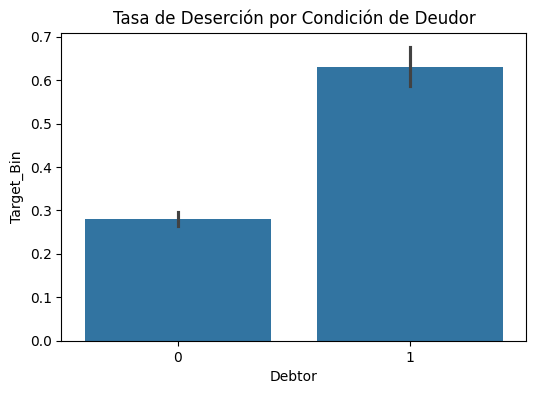

In [3]:
plt.figure(figsize=(6,4))
sns.barplot(data=train_df, x='Debtor', y='Target_Bin')
plt.title('Tasa de Deserción por Condición de Deudor')
plt.show()

**Hecho**: Los estudiantes deudores tienen una tasa de deserción mucho más alta.

**Interpretación**: El factor económico es un predictor altísimo y crítico de abandono.

**Decisión**: Esta variable se mantendrá y podría tener mucha importancia en el modelo.

## 3. Rendimiento en 1er Semestre y Notas en Cero

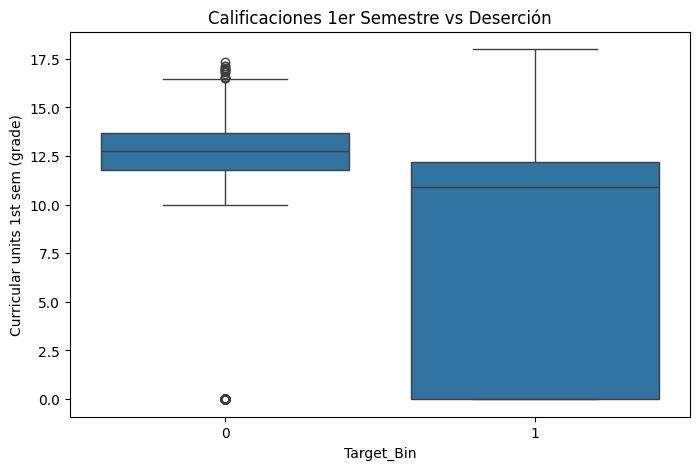

In [4]:
plt.figure(figsize=(8,5))
sns.boxplot(data=train_df, x='Target_Bin', y='Curricular units 1st sem (grade)')
plt.title('Calificaciones 1er Semestre vs Deserción')
plt.show()

In [5]:
train_df['Grade_is_0'] = train_df['Curricular units 1st sem (grade)'] == 0
train_df['Evaluations_is_0'] = train_df['Curricular units 1st sem (evaluations)'] == 0
ct = pd.crosstab([train_df['Grade_is_0'], train_df['Evaluations_is_0']], train_df['Target_Bin'], margins=True)
display(ct)
print(f"Tasa de abandono cuando Evaluaciones == 0: {train_df[train_df['Evaluations_is_0']]['Target_Bin'].mean():.1%}")
print(f"Tasa de abandono cuando Evaluaciones > 0 pero Grade == 0: {train_df[(~train_df['Evaluations_is_0']) & train_df['Grade_is_0']]['Target_Bin'].mean():.1%}")

Target_Bin                      0     1   All
Grade_is_0 Evaluations_is_0                  
False      False             2272   682  2954
True       False               40   259   299
           True                90   196   286
All                          2402  1137  3539

Tasa de abandono cuando Evaluaciones == 0: 68.5%
Tasa de abandono cuando Evaluaciones > 0 pero Grade == 0: 86.6%


**Hecho**: Los que abandonan tienen una mediana de notas drásticamente menor (muchos con nota 0). El 0 ocurre tanto cuando no hay evaluaciones (ausencia estructural, 68.5% de abandono) como cuando rinden y sacan 0 (86.6% de abandono).

**Interpretación**: Un 0 no es un error de digitación; es abandono tácito o fallo total. No hace trivial el problema (no es 100% predictivo), pero es fortísimo.

**Decisión**: Se conservan los 0s. Crearemos un feature booleano `sin_evaluaciones_1s` en el Pipeline para que el modelo separe el 'cero por ausencia' del 'cero matemático'.